In [95]:
# bibliotecas

# openpyxl para ler .xlsx
!pip install openpyxl --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [96]:
# configuração

PATH_NORMAL       = "/content/normal.xlsx"
PATH_ANOMALO_N1   = "/content/anomalo1.xlsx"
PATH_ANOMALO_N2   = "/content/anomalo2.xlsx"

# Labels e mapeamento
CLASSES = {
    "Normal":        0,
    "Anomalo_N1":    1,   # menos fita — desequilíbrio leve
    "Anomalo_N2":    2,   # mais fita  — desequilíbrio severo
}
CLASS_NAMES = list(CLASSES.keys())

# colunas de entrada
FEATURE_COLS = ["acc_x", "acc_y", "acc_z"]   # renomeadas na leitura

# parâmetros de janelamento
WINDOW_SIZE  = 26
STEP_SIZE    = 26

# valores para treinamento
LEARNING_RATE = 1e-3
VAL_SPLIT    = 0.15    # proporção de validação
TEST_SPLIT   = 0.15    # proporção de teste

In [97]:
# carregar arquivos .xlsx

def load_vibration_file(path: str, label: int, label_name: str) -> pd.DataFrame:
    print(f"  Carregando: {label_name}  →  {path}")

    df = pd.read_excel(path, header=0, usecols=[0, 1, 2, 3])

    # renomeia independente do nome original
    df.columns = ["tempo", "acc_x", "acc_y", "acc_z"]

    # remove linhas com NaN (pode haver ao final do arquivo)
    df = df.dropna().reset_index(drop=True)

    df["label"]      = label
    df["label_name"] = label_name

    print(f"    → {len(df):,} amostras  |  colunas: {list(df.columns)}")
    return df


print("Iniciando leitura dos arquivos...\n")

df_normal  = load_vibration_file(PATH_NORMAL,     0, "Normal")
df_n1      = load_vibration_file(PATH_ANOMALO_N1, 1, "Anomalo_N1")
df_n2      = load_vibration_file(PATH_ANOMALO_N2, 2, "Anomalo_N2")

# Concatena tudo
df_all = pd.concat([df_normal, df_n1, df_n2], ignore_index=True)

print(f"\nTotal de amostras: {len(df_all):,}")
print(df_all["label_name"].value_counts())

Iniciando leitura dos arquivos...

  Carregando: Normal  →  /content/normal.xlsx
    → 15,019 amostras  |  colunas: ['tempo', 'acc_x', 'acc_y', 'acc_z', 'label', 'label_name']
  Carregando: Anomalo_N1  →  /content/anomalo1.xlsx
    → 15,030 amostras  |  colunas: ['tempo', 'acc_x', 'acc_y', 'acc_z', 'label', 'label_name']
  Carregando: Anomalo_N2  →  /content/anomalo2.xlsx
    → 15,031 amostras  |  colunas: ['tempo', 'acc_x', 'acc_y', 'acc_z', 'label', 'label_name']

Total de amostras: 45,080
label_name
Anomalo_N2    15031
Anomalo_N1    15030
Normal        15019
Name: count, dtype: int64


=== Info geral ===
tempo         float64
acc_x         float64
acc_y         float64
acc_z         float64
label           int64
label_name     object
dtype: object

Valores nulos:
acc_x    0
acc_y    0
acc_z    0
dtype: int64

=== Estatísticas por classe ===
label_name     Anomalo_N1    Anomalo_N2        Normal
acc_x count  15030.000000  15031.000000  15019.000000
      mean      -0.194044     -0.218965     -0.623613
      std        4.571340     11.440790      1.188085
      min      -16.242264    -18.875887    -15.859192
      25%       -4.826711    -11.670536     -1.005565
      50%       -0.416591     -0.193930     -0.538695
      75%        4.630386     11.087548     -0.047884
      max        8.121132     17.673998      4.661511
acc_y count  15030.000000  15031.000000  15019.000000
      mean      -1.952184     -1.043348     -2.452083
      std        4.907226     10.773298      2.370247
      min      -14.252683    -19.187132    -11.614272
      25%       -6.116587    -11.34253

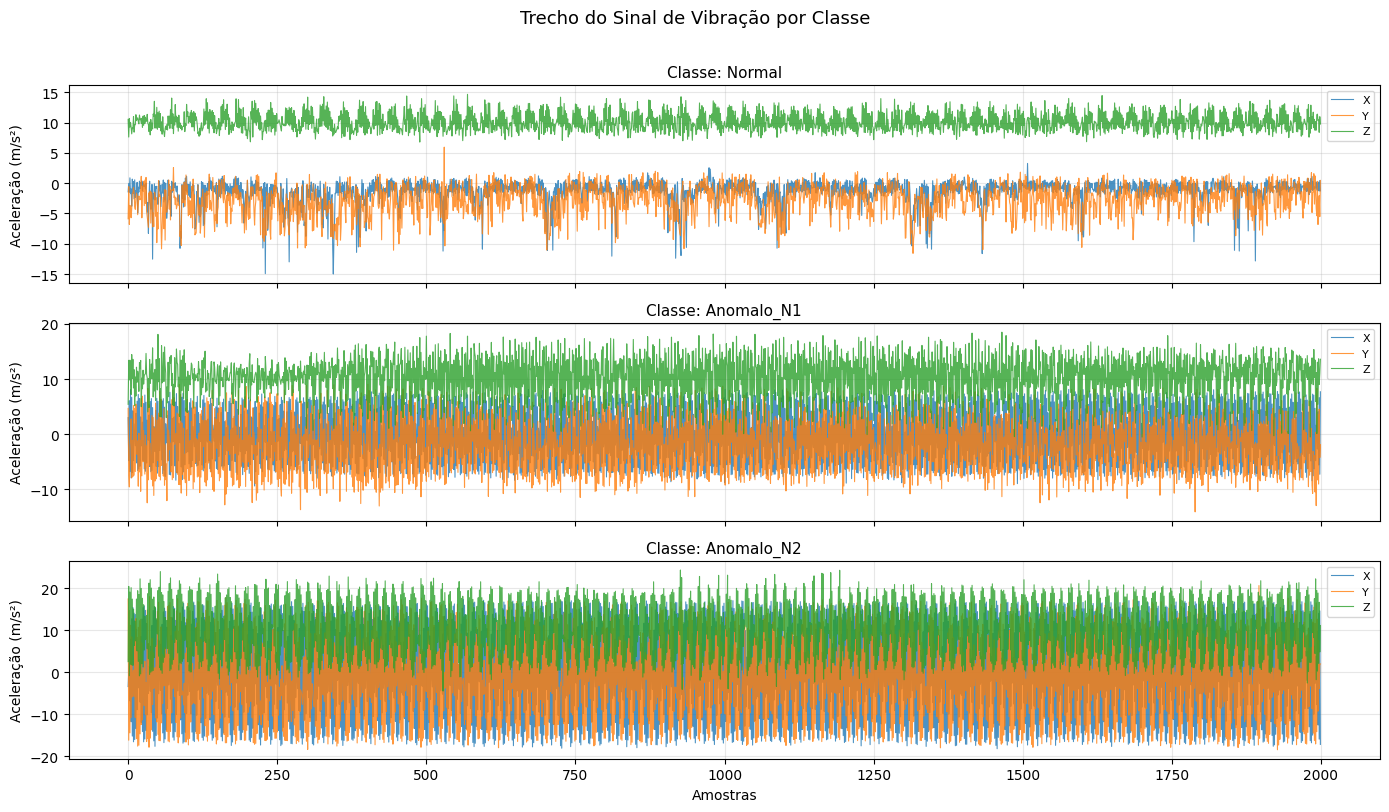

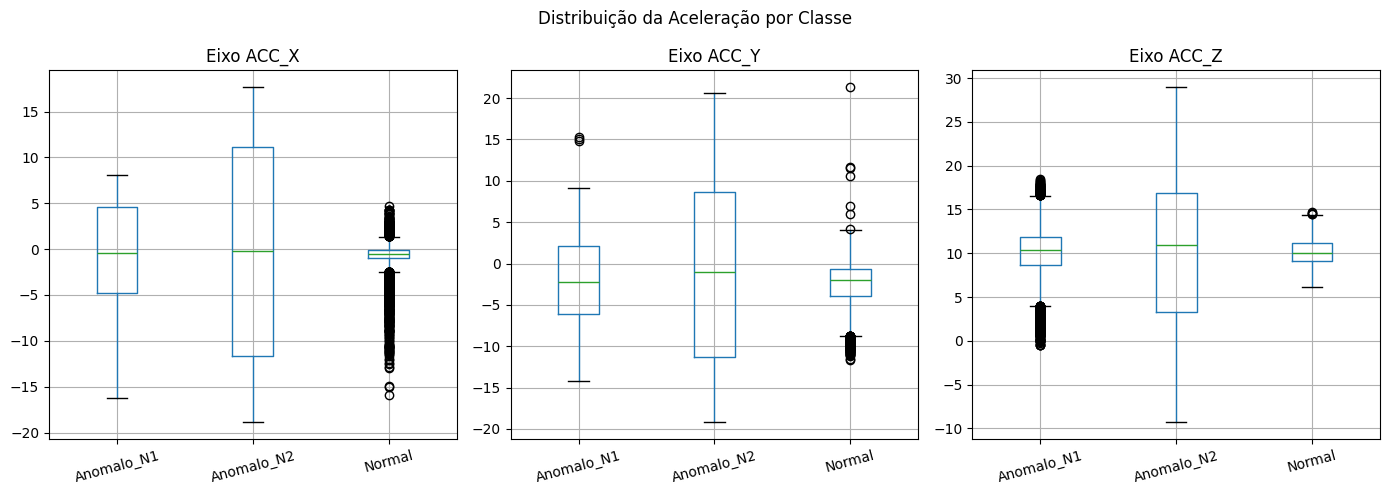


Frequência de amostragem estimada: 100.1 Hz
Duração por classe:  ≈ 2.5 min
Janela configurada:  26 amostras = 0.260 s


In [98]:
# Exploração e Verificação dos Dados

print("=== Info geral ===")
print(df_all.dtypes)
print(f"\nValores nulos:\n{df_all[FEATURE_COLS].isnull().sum()}")

print("\n=== Estatísticas por classe ===")
print(df_all.groupby("label_name")[FEATURE_COLS].describe().T)

# Plot: trecho temporal de cada classe ──
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
TRECHO = 2000   # amostras para visualizar

for ax, (name, label) in zip(axes, CLASSES.items()):
    subset = df_all[df_all["label"] == label][FEATURE_COLS].iloc[:TRECHO]
    ax.plot(subset["acc_x"].values, label="X", alpha=0.8, linewidth=0.8)
    ax.plot(subset["acc_y"].values, label="Y", alpha=0.8, linewidth=0.8)
    ax.plot(subset["acc_z"].values, label="Z", alpha=0.8, linewidth=0.8)
    ax.set_title(f"Classe: {name}", fontsize=11)
    ax.set_ylabel("Aceleração (m/s²)")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Amostras")
plt.suptitle("Trecho do Sinal de Vibração por Classe", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# distribuição das amplitudes (boxplot)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, FEATURE_COLS):
    df_all.boxplot(column=col, by="label_name", ax=ax)
    ax.set_title(f"Eixo {col.upper()}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("Distribuição da Aceleração por Classe")
plt.tight_layout()
plt.show()

# taxa de amostragem estimada
dt = df_normal["tempo"].diff().median()
fs = 1.0 / dt
print(f"\nFrequência de amostragem estimada: {fs:.1f} Hz")
print(f"Duração por classe:  ≈ {len(df_normal)/fs/60:.1f} min")
print(f"Janela configurada:  {WINDOW_SIZE} amostras = {WINDOW_SIZE/fs:.3f} s")

Gerando janelas...
Shape X: (1733, 26, 3)  →  (janelas, timesteps, eixos)
Shape y: (1733,)
Janelas por classe: [577 578 578]

Após normalização — média global: -0.0000  std: 1.0000


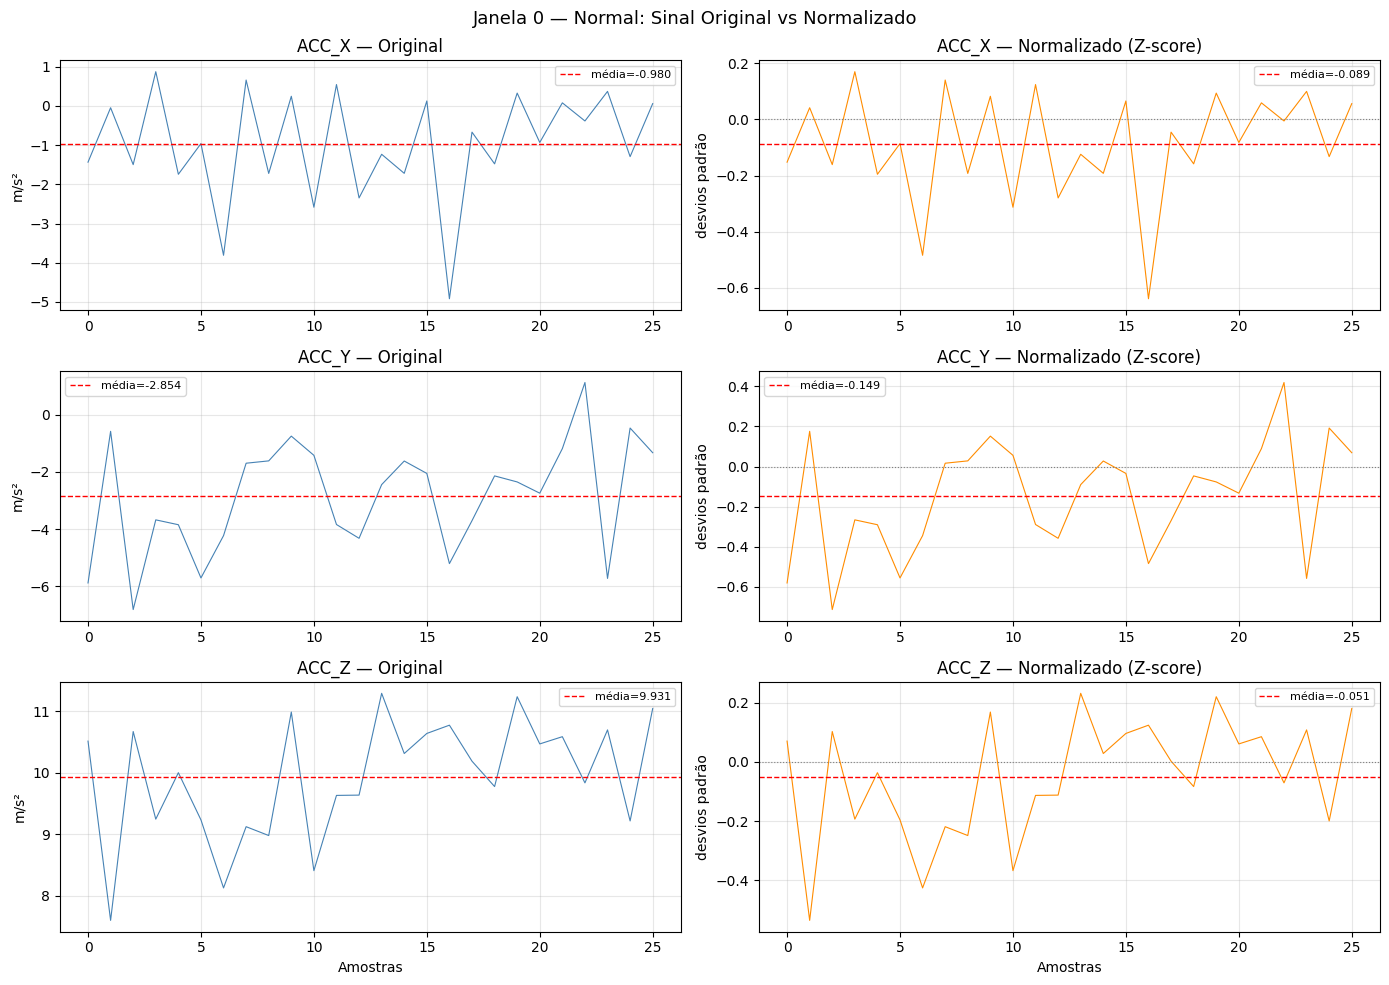

=== Estatísticas comparativas (janela 0) ===
Eixo       Média orig   Std orig   Média norm   Std norm
-------------------------------------------------------
acc_x         -0.9796     1.3695      -0.0887     0.1915
acc_y         -2.8543     1.9430      -0.1486     0.2777
acc_z          9.9313     0.9543      -0.0509     0.1984


In [99]:
# pré-processamento: Janelamento + Normalização

def create_windows(df: pd.DataFrame, window_size: int, step: int):
    """
    Recorta o sinal contínuo em janelas sobrepostas.
    Retorna arrays (N_janelas, window_size, n_features) e (N_janelas,)
    """
    signals = df[FEATURE_COLS].values.astype(np.float32)
    labels  = df["label"].values

    X_list, y_list = [], []
    n_samples = len(signals)

    for start in range(0, n_samples - window_size + 1, step):
        end = start + window_size
        window = signals[start:end]
        # Rótulo da janela = rótulo mais frequente no trecho
        label_window = int(np.bincount(labels[start:end]).argmax())
        X_list.append(window)
        y_list.append(label_window)

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int32)


print("Gerando janelas...")
X_norm, y_norm = create_windows(df_normal, WINDOW_SIZE, STEP_SIZE)
X_n1,   y_n1   = create_windows(df_n1,     WINDOW_SIZE, STEP_SIZE)
X_n2,   y_n2   = create_windows(df_n2,     WINDOW_SIZE, STEP_SIZE)

X_all = np.concatenate([X_norm, X_n1, X_n2], axis=0)
y_all = np.concatenate([y_norm, y_n1, y_n2], axis=0)

print(f"Shape X: {X_all.shape}  →  (janelas, timesteps, eixos)")
print(f"Shape y: {y_all.shape}")
print(f"Janelas por classe: {np.bincount(y_all)}")

# ── Normalização com Z-score por eixo

scaler = StandardScaler()
n, t, c = X_all.shape
X_scaled = scaler.fit_transform(X_all.reshape(-1, c)).reshape(n, t, c)
print(f"\nApós normalização — média global: {X_scaled.mean():.4f}  std: {X_scaled.std():.4f}")


# # ── Normalização por janela (Z-score local)
# n, t, c = X_all.shape
# X_scaled = np.zeros_like(X_all)
# for i in range(n):
#     for ch in range(c):
#         mean = X_all[i, :, ch].mean()
#         std  = X_all[i, :, ch].std() + 1e-8
#         X_scaled[i, :, ch] = (X_all[i, :, ch] - mean) / std

# print(f"\nApós normalização — média global: {X_scaled.mean():.4f}  std: {X_scaled.std():.4f}")

# Comparação: sinal original vs normalizado
# ... resto do código igual



# Comparação: sinal original vs normalizado
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
eixos = ["acc_x", "acc_y", "acc_z"]
janela_idx = 0  # primeira janela da classe Normal

for i, eixo in enumerate(eixos):

    # Original
    axes[i, 0].plot(X_all[janela_idx, :, i], color="steelblue", linewidth=0.8)
    axes[i, 0].set_title(f"{eixo.upper()} — Original")
    axes[i, 0].set_ylabel("m/s²")
    axes[i, 0].axhline(X_all[janela_idx, :, i].mean(), color="red",
                       linestyle="--", linewidth=1, label=f"média={X_all[janela_idx,:,i].mean():.3f}")
    axes[i, 0].legend(fontsize=8)
    axes[i, 0].grid(True, alpha=0.3)

    # Normalizado
    axes[i, 1].plot(X_scaled[janela_idx, :, i], color="darkorange", linewidth=0.8)
    axes[i, 1].set_title(f"{eixo.upper()} — Normalizado (Z-score)")
    axes[i, 1].set_ylabel("desvios padrão")
    axes[i, 1].axhline(X_scaled[janela_idx, :, i].mean(), color="red",
                       linestyle="--", linewidth=1, label=f"média={X_scaled[janela_idx,:,i].mean():.3f}")
    axes[i, 1].axhline(0, color="gray", linestyle=":", linewidth=0.8)
    axes[i, 1].legend(fontsize=8)
    axes[i, 1].grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("Amostras")

plt.suptitle("Janela 0 — Normal: Sinal Original vs Normalizado", fontsize=13)
plt.tight_layout()
plt.show()

print("=== Estatísticas comparativas (janela 0) ===")
print(f"{'Eixo':<8} {'Média orig':>12} {'Std orig':>10} {'Média norm':>12} {'Std norm':>10}")
print("-" * 55)
for i, eixo in enumerate(eixos):
    print(f"{eixo:<8} "
          f"{X_all[janela_idx,:,i].mean():>12.4f} "
          f"{X_all[janela_idx,:,i].std():>10.4f} "
          f"{X_scaled[janela_idx,:,i].mean():>12.4f} "
          f"{X_scaled[janela_idx,:,i].std():>10.4f}")

In [100]:
# divisão Temporal Treino / Validação / Teste

def temporal_split(X, y, val_frac=0.15, test_frac=0.15):
    """
    Divide janelas respeitando a ordem temporal por classe.
    Garante que treino, val e teste não compartilhem amostras sobrepostas.
    """
    X_trains, X_vals, X_tests = [], [], []
    y_trains, y_vals, y_tests = [], [], []

    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        n = len(idx)
        n_test = int(n * test_frac)
        n_val  = int(n * val_frac)

        # Fatias temporais: início→treino | meio→val | fim→teste
        idx_train = idx[:n - n_val - n_test]
        idx_val   = idx[n - n_val - n_test : n - n_test]
        idx_test  = idx[n - n_test:]

        X_trains.append(X[idx_train]); y_trains.append(y[idx_train])
        X_vals.append(X[idx_val]);     y_vals.append(y[idx_val])
        X_tests.append(X[idx_test]);   y_tests.append(y[idx_test])

    return (np.concatenate(X_trains), np.concatenate(y_trains),
            np.concatenate(X_vals),   np.concatenate(y_vals),
            np.concatenate(X_tests),  np.concatenate(y_tests))


X_train, y_train, X_val, y_val, X_test, y_test = temporal_split(
    X_scaled, y_all, val_frac=VAL_SPLIT, test_frac=TEST_SPLIT
)

# Shuffle apenas o treino (val e teste permanecem na ordem)
SEED = 42
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(X_train))
X_train, y_train = X_train[perm], y_train[perm]

print(f"Treino:     {X_train.shape}  |  {np.bincount(y_train)}")
print(f"Validação:  {X_val.shape}    |  {np.bincount(y_val)}")
print(f"Teste:      {X_test.shape}   |  {np.bincount(y_test)}")

y_train_cat = keras.utils.to_categorical(y_train, num_classes=len(CLASSES))
y_val_cat   = keras.utils.to_categorical(y_val,   num_classes=len(CLASSES))
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes=len(CLASSES))

INPUT_SHAPE = (WINDOW_SIZE, len(FEATURE_COLS))
print(f"\nInput shape do modelo: {INPUT_SHAPE}")

Treino:     (1217, 26, 3)  |  [405 406 406]
Validação:  (258, 26, 3)    |  [86 86 86]
Teste:      (258, 26, 3)   |  [86 86 86]

Input shape do modelo: (26, 3)


In [101]:
# modelo

def build_cnn1d(input_shape: tuple, n_classes: int) -> keras.Model:
    inputs = keras.Input(shape=input_shape, name="vibration_input")

    # ── Bloco 1: captura padrões locais grosseiros ──
    x = layers.Conv1D(16, kernel_size=7, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=4)(x)

    # ── Bloco 2: padrões de médio prazo ──
    x = layers.Conv1D(32, kernel_size=5, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=4)(x)

    # ── Bloco 3: abstração final ──
    x = layers.Conv1D(32, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # ── Classificador mínimo ──
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="output")(x)

    model = keras.Model(inputs, outputs, name="TinyCNN1D_Drone")
    return model


model = build_cnn1d(INPUT_SHAPE, n_classes=len(CLASSES))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "TinyCNN1D_Drone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vibration_input (InputLayer)    │ (None, 26, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 26, 16)         │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 26, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 26, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 6, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 6, 32)          │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 6, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_19 (ReLU)                 │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 1, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 1, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,467 (25.26 KB)

 Trainable params: 6,307 (24.64 KB)

 Non-trainable params: 160 (640.00 B)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.7584 - loss: 0.5901 - val_accuracy: 0.4302 - val_loss: 0.9311 - learning_rate: 0.0010
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9491 - loss: 0.2388 - val_accuracy: 0.7829 - val_loss: 0.7108 - learning_rate: 0.0010
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9951 - loss: 0.1327 - val_accuracy: 1.0000 - val_loss: 0.5246 - learning_rate: 0.0010
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9934 - loss: 0.1017 - val_accuracy: 1.0000 - val_loss: 0.3903 - learning_rate: 0.0010
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9984 - loss: 0.0778 - val_accuracy: 1.0000 - val_loss: 0.2924 - learning_rate: 0.0010
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9992 - loss: 0.0575 - val_accuracy: 1.0000 - val_loss: 0.2111 - learning_rate: 0.0010
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9975 - loss: 0.0493 - val_accu

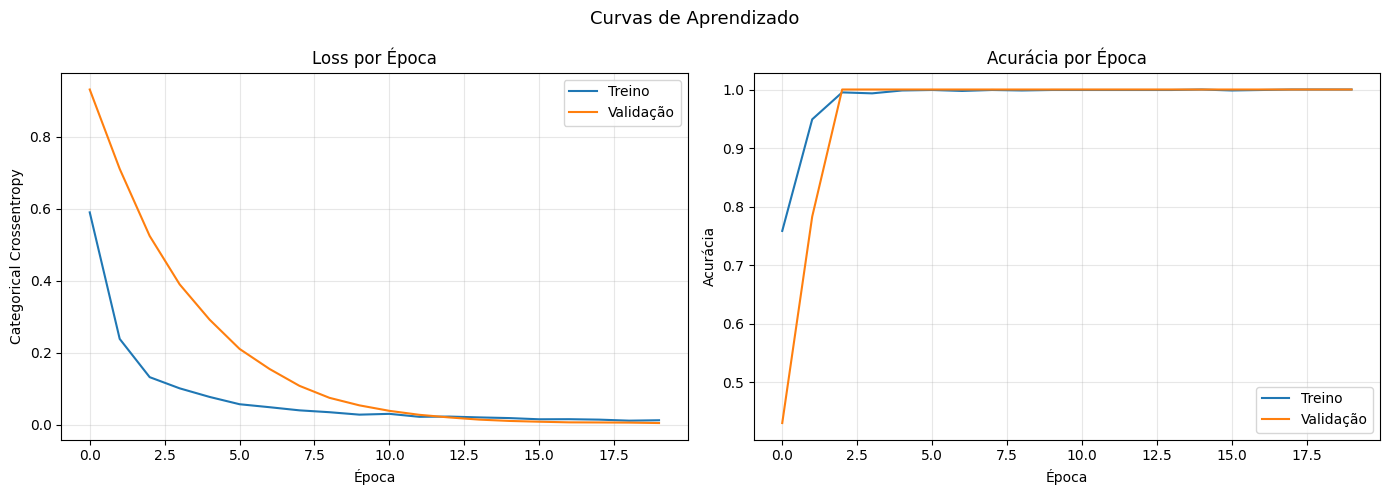

In [102]:
# treinamento

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=0
    )
]

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# Plot do aprendizado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"],     label="Treino")
axes[0].plot(history.history["val_loss"], label="Validação")
axes[0].set_title("Loss por Época")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Categorical Crossentropy")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["accuracy"],     label="Treino")
axes[1].plot(history.history["val_accuracy"], label="Validação")
axes[1].set_title("Acurácia por Época")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Curvas de Aprendizado", fontsize=13)
plt.tight_layout()
plt.show()

Loss no Teste:     0.0066
Acurácia no Teste: 100.00%

=== Relatório de Classificação ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        86
  Anomalo_N1       1.00      1.00      1.00        86
  Anomalo_N2       1.00      1.00      1.00        86

    accuracy                           1.00       258
   macro avg       1.00      1.00      1.00       258
weighted avg       1.00      1.00      1.00       258



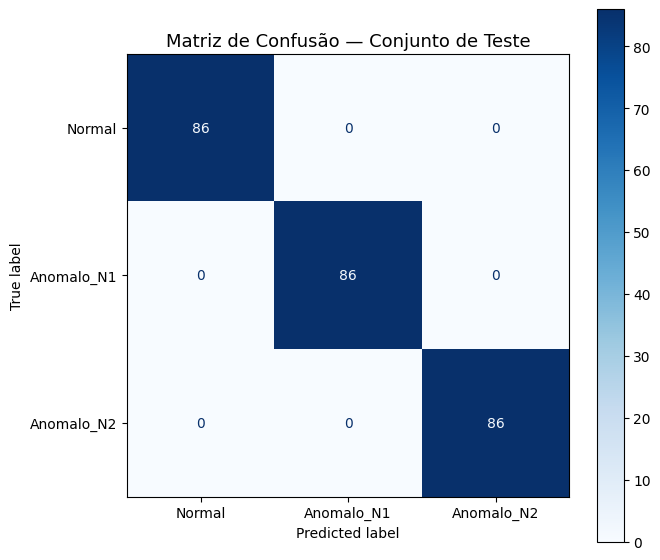

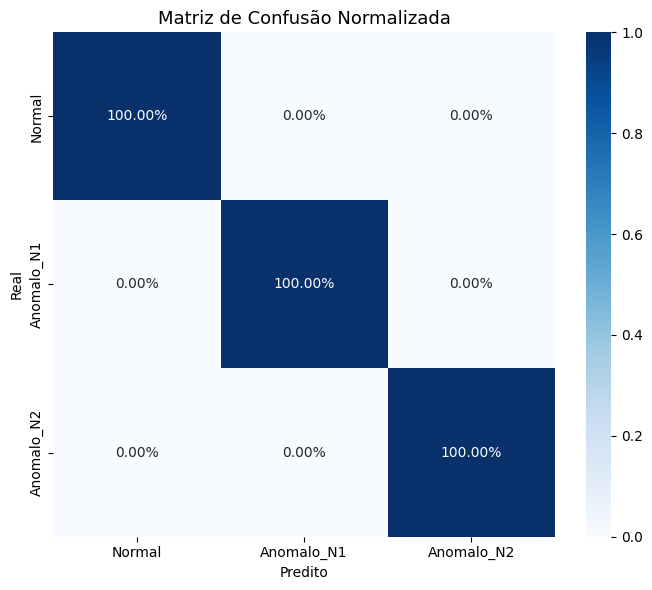

In [103]:
# Avaliação do modelo

# Métricas gerais
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Loss no Teste:     {test_loss:.4f}")
print(f"Acurácia no Teste: {test_acc*100:.2f}%\n")

# Predições
y_pred_prob = model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

# Relatório por classe
print("=== Relatório de Classificação ===")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Matriz de Confusão — Conjunto de Teste", fontsize=13)
plt.tight_layout()
plt.show()

# Matriz de Confusão Normalizada
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predito"); ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão Normalizada", fontsize=13)
plt.tight_layout()
plt.show()

## Seção 10 — Visualizar Modelo no Netron

Baixe o arquivo do modelo e abra em: [https://netron.app](https://netron.app)

In [104]:
# baixa o modelo para abrir no Netron

# from google.colab import files
# files.download("/content/best_model.keras")

In [105]:
# Conversão para TFLite


converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# salva o arquivo
with open("drone_fault.tflite", "wb") as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"Modelo TFLite salvo: drone_fault.tflite")
print(f"Tamanho: {size_kb:.2f} KB")

Saved artifact at '/tmp/tmp7k5jr4ai'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 26, 3), dtype=tf.float32, name='vibration_input')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140354981480784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981491920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981485200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981482320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981479440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981490576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981485008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981492496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981478480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981482128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981490192: 

In [106]:
# quantiza apenas os pesos de float32 para int8


converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model_quant = converter.convert()

with open("drone_fault_quant.tflite", "wb") as f:
    f.write(tflite_model_quant)

size_orig_kb  = len(tflite_model) / 1024
size_quant_kb = len(tflite_model_quant) / 1024

print(f"Sem quantização:        {size_orig_kb:.2f} KB")
print(f"Dynamic range quant:    {size_quant_kb:.2f} KB")
print(f"Redução:                {(1 - size_quant_kb/size_orig_kb)*100:.1f}%")

Saved artifact at '/tmp/tmpd_asm97m'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 26, 3), dtype=tf.float32, name='vibration_input')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140354981480784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981491920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981485200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981482320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981479440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981490576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981485008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981492496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981478480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981482128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981490192: 

In [107]:
# Quantização int8

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_dataset():
    for i in range(0, min(500, len(X_train)), 1):
        yield [X_train[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32

tflite_model_int8 = converter.convert()

with open("drone_fault_int8.tflite", "wb") as f:
    f.write(tflite_model_int8)

size_int8_kb = len(tflite_model_int8) / 1024

print(f"Sem quantização:        {size_orig_kb:.2f} KB")
print(f"Dynamic range:          {size_quant_kb:.2f} KB")
print(f"int8 completo:          {size_int8_kb:.2f} KB")
print(f"Redução total:          {(1 - size_int8_kb/size_orig_kb)*100:.1f}%")

# valida o modelo quantizado no conjunto de teste
interpreter = tf.lite.Interpreter(model_content=tflite_model_int8)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"\nInput:  shape={input_details[0]['shape']},  dtype={input_details[0]['dtype']}")
print(f"Output: shape={output_details[0]['shape']}, dtype={output_details[0]['dtype']}")

correct = 0
for i in range(len(X_test)):
    sample = X_test[i:i+1].astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    pred = interpreter.get_tensor(output_details[0]['index'])
    if np.argmax(pred) == y_test[i]:
        correct += 1

acc_int8 = correct / len(X_test)
print(f"\nAcurácia modelo Keras original: {model.evaluate(X_test, y_test_cat, verbose=0)[1]*100:.2f}%")
print(f"Acurácia modelo int8:           {acc_int8*100:.2f}%")

Saved artifact at '/tmp/tmpxj56ll08'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 26, 3), dtype=tf.float32, name='vibration_input')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140354981480784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981491920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981485200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981482320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981479440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981490576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981485008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981492496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981478480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981482128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354981490192: 

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [108]:
# converte o .tflite em array C

# via xxd
MODEL_TFLITE       = "drone_fault_int8.tflite"
MODEL_TFLITE_MICRO = "drone_fault_model.cc"

!xxd -i {MODEL_TFLITE} > {MODEL_TFLITE_MICRO}

# renomeia o array para g_model
import re
REPLACE_TEXT = MODEL_TFLITE.replace("/", "_").replace(".", "_")
with open(MODEL_TFLITE_MICRO, "r") as f:
    content = f.read()
content = content.replace(REPLACE_TEXT, "g_model")
with open(MODEL_TFLITE_MICRO, "w") as f:
    f.write(content)

print(f"Arquivo gerado: {MODEL_TFLITE_MICRO}")
!head -5 {MODEL_TFLITE_MICRO}
!tail -3 {MODEL_TFLITE_MICRO}

# faz download dos dois arquivos ──
from google.colab import files
files.download("drone_fault_int8.tflite")
files.download("drone_fault_model.cc")

Arquivo gerado: drone_fault_model.cc
unsigned char g_model[] = {
  0x20, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x00, 0x00, 0x00, 0x00,
  0x14, 0x00, 0x20, 0x00, 0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00,
  0x1c, 0x00, 0x00, 0x00, 0x8c, 0x00, 0x00, 0x00, 0xe4, 0x00, 0x00, 0x00,
  0x72, 0x00, 0x00, 0x00, 0x00, 0x00, 0x00, 0x72
};
unsigned int g_model_len = 17288;


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [109]:
print("SCALER_MEAN: ", scaler.mean_.tolist())
print("SCALER_SCALE:", scaler.scale_.tolist())

SCALER_MEAN:  [-0.34533258772076825, -1.814758926962374, 10.176024291173649]
SCALER_SCALE: [7.150777188683148, 6.996518283765137, 4.811400555817722]


In [110]:
# !jupyter nbconvert --to html /content/Classificador_Vibracao_Drone_TinyML.ipynb